Device: cpu

Running: zero


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Loss: 3.5882 | Val Accuracy: 0.00%

Running: random
Loss: 2.0341 | Val Accuracy: 0.00%

Running: xavier
Loss: 2.1055 | Val Accuracy: 0.00%

Running: he
Loss: 2.0035 | Val Accuracy: 0.00%


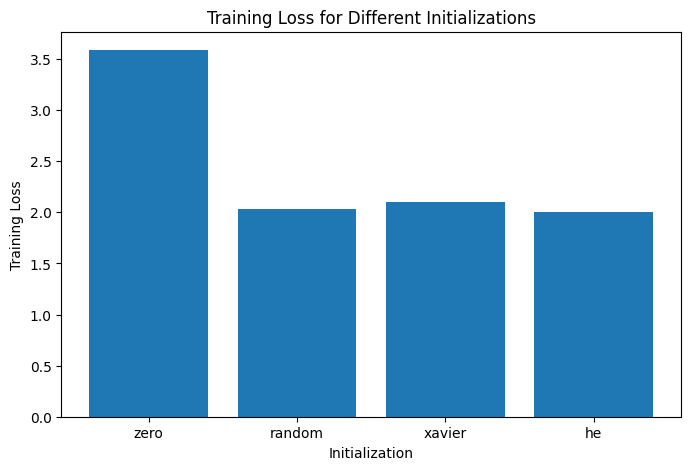

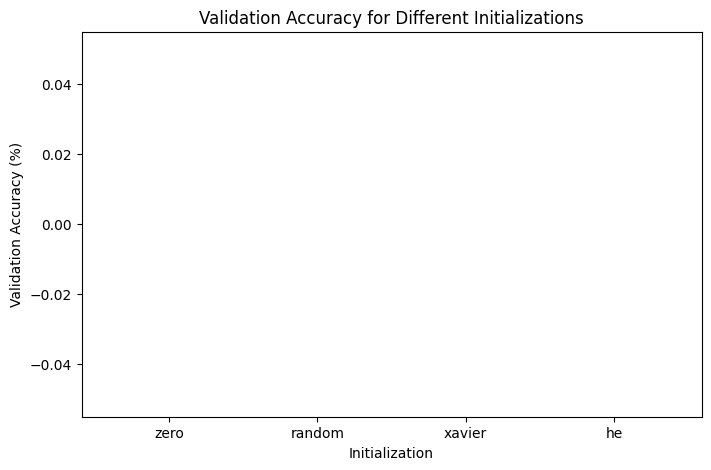

In [ ]:
# ============================================================
# TASK 1 - WEIGHT INITIALIZATION
# MEMORY OPTIMIZED / FAST
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# ---------------- DEVICE ----------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ---------------- DATA ----------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

# ONLY 300 IMAGES
dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))

train_loader = DataLoader(
    train_data,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# ---------------- MODEL ----------------
def create_model(method):

    model = models.mobilenet_v2(weights=None)

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        37
    )

    for layer in model.modules():

        if isinstance(layer, (nn.Conv2d, nn.Linear)):

            if method == "zero":
                nn.init.zeros_(layer.weight)

            elif method == "random":
                nn.init.normal_(
                    layer.weight,
                    0,
                    0.02
                )

            elif method == "xavier":
                nn.init.xavier_uniform_(
                    layer.weight
                )

            elif method == "he":
                nn.init.kaiming_normal_(
                    layer.weight,
                    nonlinearity="relu"
                )

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    return model.to(device)

# ---------------- TRAIN ----------------
def run_model(model):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(device.type == "cuda")
    )

    train_loss = 0

    # 1 EPOCH ONLY
    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------- VALIDATION ----------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=(device.type == "cuda")
            ):

                outputs = model(images)

            predictions = outputs.argmax(1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return train_loss, accuracy


# ---------------- RUN ----------------
methods = [
    "zero",
    "random",
    "xavier",
    "he"
]

losses = []
accuracies = []

for method in methods:

    print("\nRunning:", method)

    model = create_model(method)

    loss, accuracy = run_model(model)

    losses.append(loss)
    accuracies.append(accuracy)

    print(
        f"Loss: {loss:.4f} | "
        f"Val Accuracy: {accuracy:.2f}%"
    )

    # FREE MEMORY
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ---------------- PLOT 1 ----------------
plt.figure(figsize=(8,5))

plt.bar(methods, losses)

plt.xlabel("Initialization")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Initializations")

plt.show()


# ---------------- PLOT 2 ----------------
plt.figure(figsize=(8,5))

plt.bar(methods, accuracies)

plt.xlabel("Initialization")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Different Initializations")

plt.show()

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))q

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Device: cuda


100%|██████████| 792M/792M [00:29<00:00, 26.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.77MB/s]



Running: No Regularization
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s]


Train Loss: 2.5885 | Val Loss: 4.1383 | Train Acc: 30.42% | Val Acc: 8.33%

Running: L2
Train Loss: 2.7008 | Val Loss: 4.1049 | Train Acc: 27.92% | Val Acc: 5.00%

Running: Dropout
Train Loss: 2.7113 | Val Loss: 4.0384 | Train Acc: 27.08% | Val Acc: 5.00%


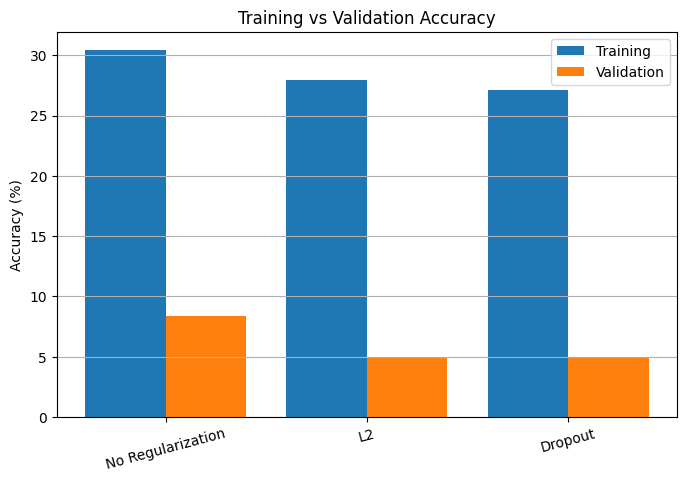

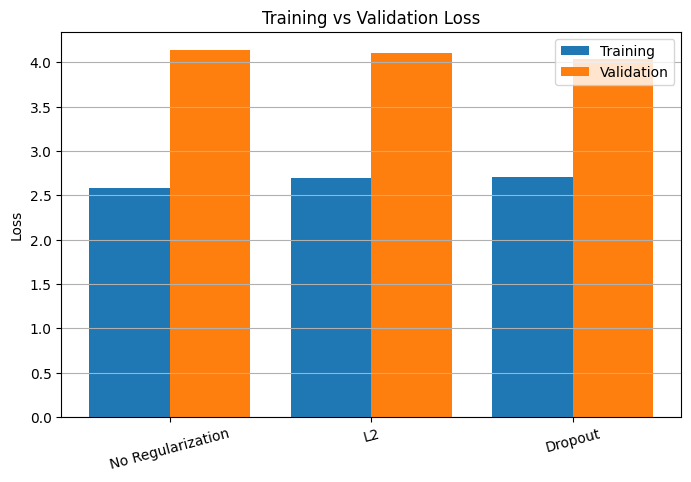

In [2]:
# ============================================================
# TASK 2 - REGULARIZATION
# No Regularization vs L2 vs Dropout
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

# Small dataset
dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# MODEL
def create_model(dropout):

    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.DEFAULT
    )

    # Freeze feature extractor
    for p in model.features.parameters():
        p.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(model.last_channel, 37)
    )

    return model.to(device)


# TRAIN + VALIDATE
def run(dropout=0, weight_decay=0):

    model = create_model(dropout)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.classifier.parameters(),
        lr=0.001,
        weight_decay=weight_decay
    )

    # TRAIN
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        output = model(x)

        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = output.argmax(1)

        train_correct += (pred == y).sum().item()
        train_total += y.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # VALIDATION
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            output = model(x)

            val_loss += criterion(output, y).item()

            pred = output.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total

    # FREE MEMORY
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return train_loss, val_loss, train_acc, val_acc


# EXPERIMENTS
configs = {
    "No Regularization": (0, 0),
    "L2": (0, 1e-4),
    "Dropout": (0.5, 0)
}

results = {}

for name, (dropout, l2) in configs.items():

    print("\nRunning:", name)

    results[name] = run(
        dropout,
        l2
    )

    print(
        f"Train Loss: {results[name][0]:.4f} | "
        f"Val Loss: {results[name][1]:.4f} | "
        f"Train Acc: {results[name][2]:.2f}% | "
        f"Val Acc: {results[name][3]:.2f}%"
    )


# PLOT 3 - ACCURACY
names = list(results.keys())

train_acc = [results[x][2] for x in names]
val_acc = [results[x][3] for x in names]

plt.figure(figsize=(8, 5))

x = range(len(names))

plt.bar(
    [i - 0.2 for i in x],
    train_acc,
    width=0.4,
    label="Training"
)

plt.bar(
    [i + 0.2 for i in x],
    val_acc,
    width=0.4,
    label="Validation"
)

plt.xticks(x, names, rotation=15)
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(axis="y")

plt.show()


# PLOT 4 - LOSS
train_loss = [results[x][0] for x in names]
val_loss = [results[x][1] for x in names]

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    train_loss,
    width=0.4,
    label="Training"
)

plt.bar(
    [i + 0.2 for i in x],
    val_loss,
    width=0.4,
    label="Validation"
)

plt.xticks(x, names, rotation=15)
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(axis="y")

plt.show()

Device: cuda
Running WITH BatchNorm...
Running WITHOUT BatchNorm...

With BN: 10.0
Without BN: 13.333333333333334


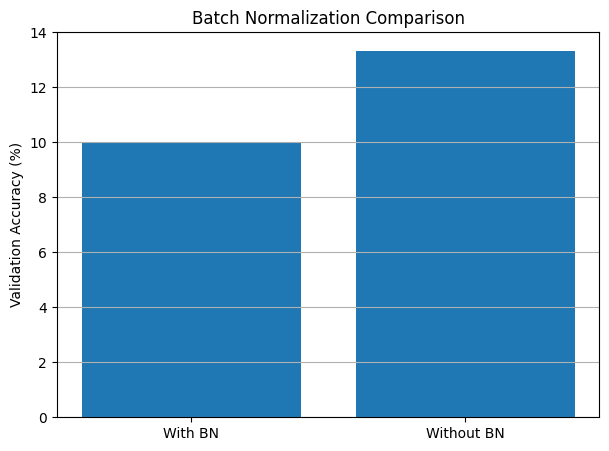


Numerical Example
Mean: 5.0
Variance: 5.0
Normalized: tensor([-1.3416, -0.4472,  0.4472,  1.3416])


In [3]:
# ============================================================
# TASK 3 - BATCH NORMALIZATION
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# REMOVE BATCH NORMALIZATION
def remove_bn(module):

    for name, child in module.named_children():

        if isinstance(child, nn.BatchNorm2d):

            setattr(
                module,
                name,
                nn.Identity()
            )

        else:
            remove_bn(child)


# MODEL
def create_model(use_bn):

    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.DEFAULT
    )

    if not use_bn:
        remove_bn(model)

    for p in model.features.parameters():
        p.requires_grad = False

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        37
    )

    return model.to(device)


# RUN
def run(use_bn):

    model = create_model(use_bn)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.classifier.parameters(),
        lr=0.001
    )

    model.train()

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        output = model(x)

        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            output = model(x)

            pred = output.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    accuracy = 100 * correct / total

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return accuracy


# EXPERIMENT
print("Running WITH BatchNorm...")
with_bn = run(True)

print("Running WITHOUT BatchNorm...")
without_bn = run(False)

print("\nWith BN:", with_bn)
print("Without BN:", without_bn)


# PLOT
plt.figure(figsize=(7, 5))

plt.bar(
    ["With BN", "Without BN"],
    [with_bn, without_bn]
)

plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Normalization Comparison")
plt.grid(axis="y")

plt.show()


# NUMERICAL EXAMPLE
x = torch.tensor([2., 4., 6., 8.])

mean = x.mean()
variance = ((x - mean) ** 2).mean()

normalized = (
    (x - mean) /
    torch.sqrt(variance + 1e-5)
)

print("\nNumerical Example")
print("Mean:", mean.item())
print("Variance:", variance.item())
print("Normalized:", normalized)

Device: cuda

Running: SGD
Loss: 3.6318 | Accuracy: 0.00%

Running: Momentum
Loss: 3.6175 | Accuracy: 1.67%

Running: RMSProp
Loss: 1.4825 | Accuracy: 11.67%

Running: Adam
Loss: 2.6938 | Accuracy: 0.00%


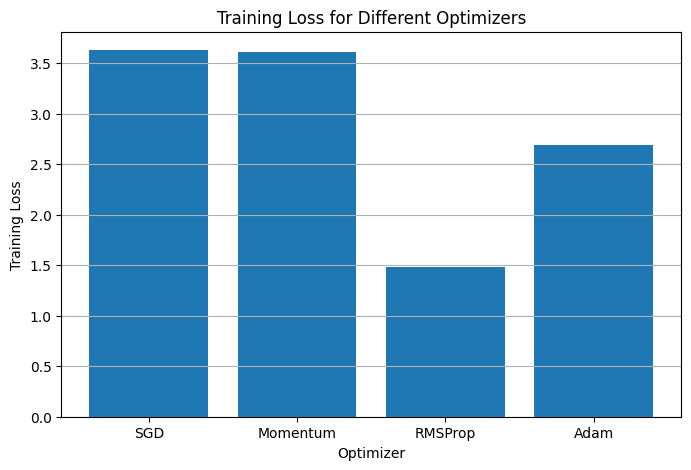

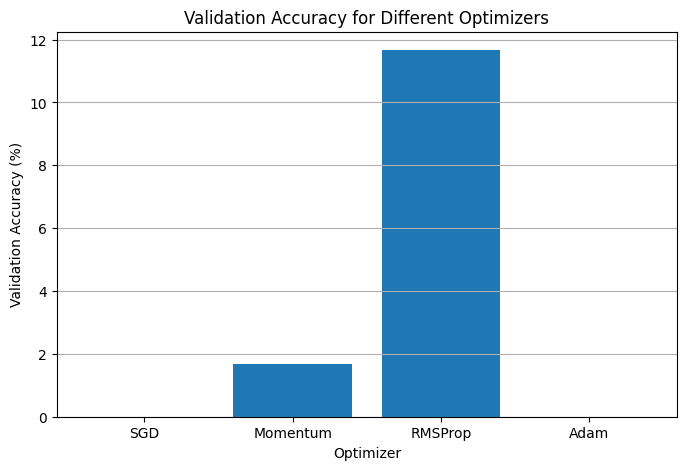


RESULT TABLE
  Optimizer  Final Loss  Validation Accuracy (%)
0       SGD    3.631817                 0.000000
1  Momentum    3.617455                 1.666667
2   RMSProp    1.482491                11.666667
3      Adam    2.693779                 0.000000


In [4]:
# ============================================================
# TASK 4 - OPTIMIZERS
# SGD / MOMENTUM / RMSPROP / ADAM
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# MODEL
def create_model():

    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.DEFAULT
    )

    for p in model.features.parameters():
        p.requires_grad = False

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        37
    )

    return model.to(device)


# RUN
def run(name):

    model = create_model()

    if name == "SGD":

        optimizer = optim.SGD(
            model.classifier.parameters(),
            lr=0.001
        )

    elif name == "Momentum":

        optimizer = optim.SGD(
            model.classifier.parameters(),
            lr=0.001,
            momentum=0.9
        )

    elif name == "RMSProp":

        optimizer = optim.RMSprop(
            model.classifier.parameters(),
            lr=0.001
        )

    else:

        optimizer = optim.Adam(
            model.classifier.parameters(),
            lr=0.001
        )

    criterion = nn.CrossEntropyLoss()

    model.train()

    total_loss = 0

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        output = model(x)

        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            output = model(x)

            pred = output.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    val_accuracy = 100 * correct / total

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return train_loss, val_accuracy


optimizers_list = [
    "SGD",
    "Momentum",
    "RMSProp",
    "Adam"
]

results = {}

for name in optimizers_list:

    print("\nRunning:", name)

    results[name] = run(name)

    print(
        f"Loss: {results[name][0]:.4f} | "
        f"Accuracy: {results[name][1]:.2f}%"
    )


# PLOT 6
plt.figure(figsize=(8, 5))

plt.bar(
    optimizers_list,
    [results[x][0] for x in optimizers_list]
)

plt.xlabel("Optimizer")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Optimizers")
plt.grid(axis="y")

plt.show()


# PLOT 7
plt.figure(figsize=(8, 5))

plt.bar(
    optimizers_list,
    [results[x][1] for x in optimizers_list]
)

plt.xlabel("Optimizer")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy for Different Optimizers")
plt.grid(axis="y")

plt.show()


# TABLE
df = pd.DataFrame({
    "Optimizer": optimizers_list,
    "Final Loss": [
        results[x][0]
        for x in optimizers_list
    ],
    "Validation Accuracy (%)": [
        results[x][1]
        for x in optimizers_list
    ]
})

print("\nRESULT TABLE")
print(df)

Device: cuda
Learning Rate: 0.001
Learning Rate: 0.0001


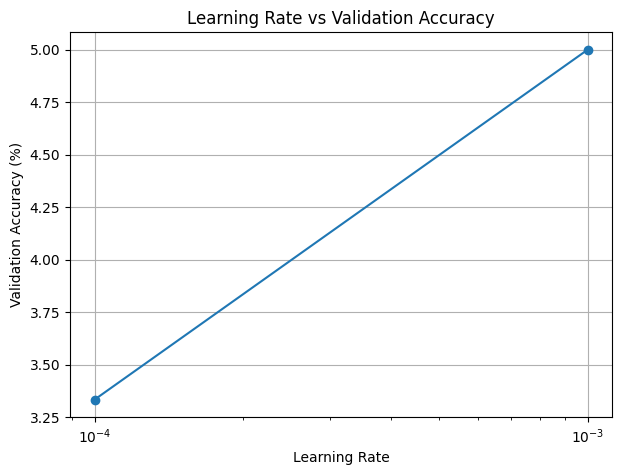

Batch Size: 16
Batch Size: 32
Batch Size: 64


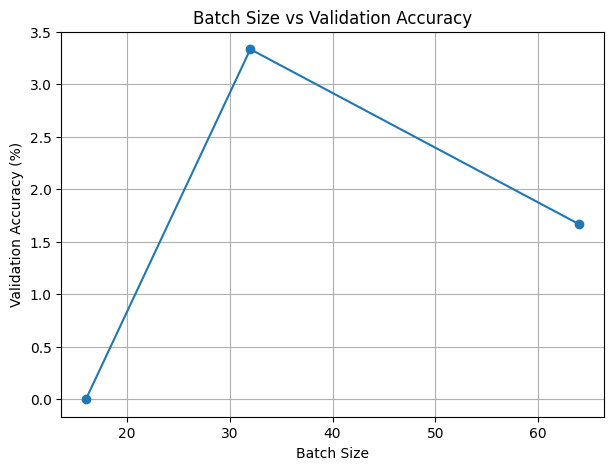

Dropout: 0
Dropout: 0.25
Dropout: 0.5


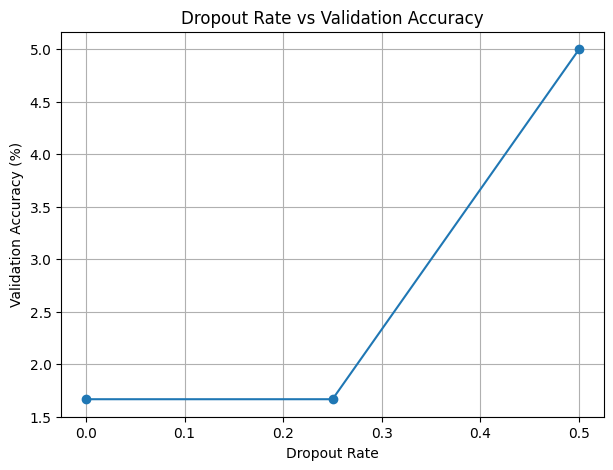


LR Results: [5.0, 3.3333333333333335]
Batch Results: [0.0, 3.3333333333333335, 1.6666666666666667]
Dropout Results: [1.6666666666666667, 1.6666666666666667, 5.0]


In [5]:
# ============================================================
# TASK 5 - HYPERPARAMETER TUNING
# Learning Rate / Batch Size / Dropout
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))


# RUN EXPERIMENT
def run(
    lr=0.001,
    batch_size=32,
    dropout=0
):

    train_loader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    model = models.mobilenet_v2(
        weights=models.MobileNet_V2_Weights.DEFAULT
    )

    # Freeze base
    for p in model.features.parameters():
        p.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(model.last_channel, 37)
    )

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.classifier.parameters(),
        lr=lr
    )

    # ONE EPOCH
    model.train()

    for x, y in train_loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)

        output = model(x)

        loss = criterion(output, y)

        loss.backward()
        optimizer.step()

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(device)
            y = y.to(device)

            output = model(x)

            pred = output.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    accuracy = 100 * correct / total

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return accuracy


# ============================================================
# LEARNING RATE
# ============================================================

lr_values = [0.001, 0.0001]

lr_results = []

for lr in lr_values:

    print("Learning Rate:", lr)

    lr_results.append(
        run(lr=lr)
    )

plt.figure(figsize=(7, 5))

plt.plot(
    lr_values,
    lr_results,
    marker="o"
)

plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Learning Rate vs Validation Accuracy")
plt.grid()

plt.show()


# ============================================================
# BATCH SIZE
# ============================================================

batch_values = [16, 32, 64]

batch_results = []

for batch in batch_values:

    print("Batch Size:", batch)

    batch_results.append(
        run(batch_size=batch)
    )

plt.figure(figsize=(7, 5))

plt.plot(
    batch_values,
    batch_results,
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Batch Size vs Validation Accuracy")
plt.grid()

plt.show()


# ============================================================
# DROPOUT
# ============================================================

drop_values = [0, 0.25, 0.5]

drop_results = []

for dropout in drop_values:

    print("Dropout:", dropout)

    drop_results.append(
        run(dropout=dropout)
    )

plt.figure(figsize=(7, 5))

plt.plot(
    drop_values,
    drop_results,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Rate vs Validation Accuracy")
plt.grid()

plt.show()


print("\nLR Results:", lr_results)
print("Batch Results:", batch_results)
print("Dropout Results:", drop_results)

Device: cuda

Feature Extraction
Training Loss: 2.670030862092972
Validation Accuracy: 1.6666666666666667 %


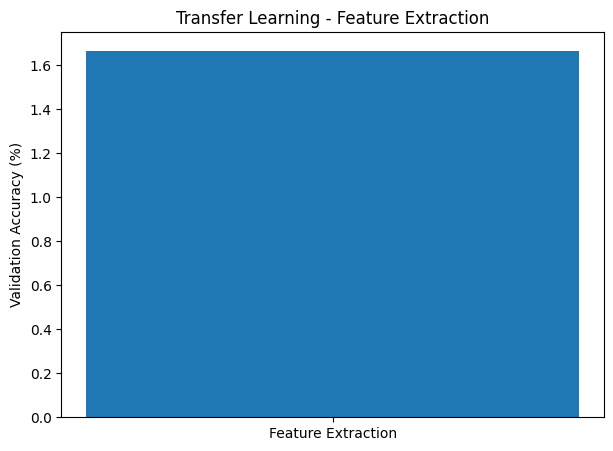

In [6]:
# ============================================================
# TASK 6 - TRANSFER LEARNING / FEATURE EXTRACTION
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# PRETRAINED MODEL
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

# FREEZE FEATURE EXTRACTOR
for p in model.features.parameters():
    p.requires_grad = False

# NEW CLASSIFIER
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    37
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

# TRAIN
model.train()

train_loss = 0

for x, y in train_loader:

    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad(set_to_none=True)

    output = model(x)

    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

train_loss /= len(train_loader)

# VALIDATION
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(device)
        y = y.to(device)

        output = model(x)

        pred = output.argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

accuracy = 100 * correct / total

print("\nFeature Extraction")
print("Training Loss:", train_loss)
print("Validation Accuracy:", accuracy, "%")

# PLOT
plt.figure(figsize=(7, 5))

plt.bar(
    ["Feature Extraction"],
    [accuracy]
)

plt.ylabel("Validation Accuracy (%)")
plt.title("Transfer Learning - Feature Extraction")

plt.show()

Device: cuda

Fine-Tuning Results
Training Loss: 3.546568274497986
Validation Loss: 3.7391915321350098
Validation Accuracy: 0.0 %


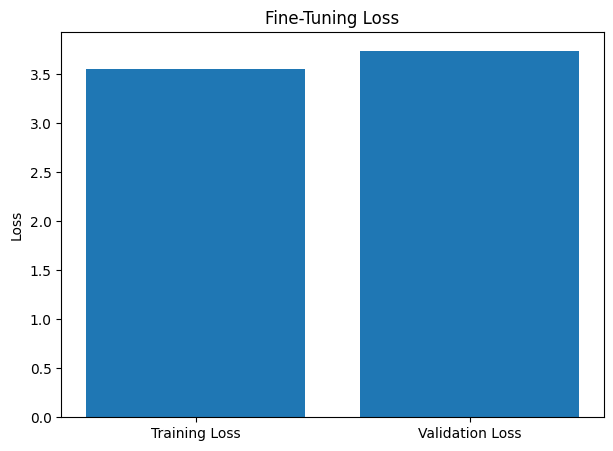

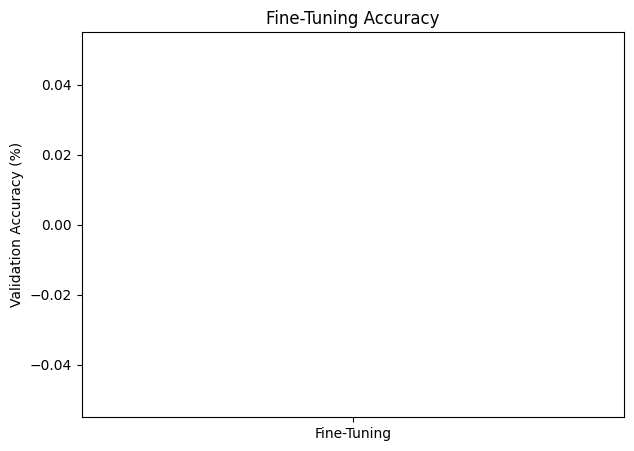

In [7]:
# ============================================================
# TASK 7 - FINE-TUNING
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

dataset = Subset(dataset, range(300))

train_data = Subset(dataset, range(240))
val_data = Subset(dataset, range(240, 300))

train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# PRETRAINED MODEL
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

# FREEZE ALL
for p in model.features.parameters():
    p.requires_grad = False

# UNFREEZE LAST 2 BLOCKS
for p in model.features[-2:].parameters():
    p.requires_grad = True

# NEW CLASSIFIER
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    37
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

# SMALL LEARNING RATE
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-5
)

# TRAIN
model.train()

train_loss = 0

for x, y in train_loader:

    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad(set_to_none=True)

    output = model(x)

    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

train_loss /= len(train_loader)

# VALIDATION
model.eval()

val_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(device)
        y = y.to(device)

        output = model(x)

        val_loss += criterion(
            output,
            y
        ).item()

        pred = output.argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

val_loss /= len(val_loader)

accuracy = 100 * correct / total

print("\nFine-Tuning Results")
print("Training Loss:", train_loss)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", accuracy, "%")


# PLOT
plt.figure(figsize=(7, 5))

plt.bar(
    ["Training Loss", "Validation Loss"],
    [train_loss, val_loss]
)

plt.ylabel("Loss")
plt.title("Fine-Tuning Loss")

plt.show()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Fine-Tuning"],
    [accuracy]
)

plt.ylabel("Validation Accuracy (%)")
plt.title("Fine-Tuning Accuracy")

plt.show()

del model
gc.collect()
torch.cuda.empty_cache()

Device: cuda

C1
Fold 1
Accuracy: 5.00%
Fold 2
Accuracy: 5.00%
Fold 3
Accuracy: 10.00%
Fold 4
Accuracy: 10.00%
Fold 5
Accuracy: 5.00%
Mean ± SD: 7.00 ± 2.45

C2
Fold 1
Accuracy: 5.00%
Fold 2
Accuracy: 30.00%
Fold 3
Accuracy: 15.00%
Fold 4
Accuracy: 5.00%
Fold 5
Accuracy: 10.00%
Mean ± SD: 13.00 ± 9.27

C3
Fold 1
Accuracy: 2.50%
Fold 2
Accuracy: 5.00%
Fold 3
Accuracy: 0.00%
Fold 4
Accuracy: 0.00%
Fold 5
Accuracy: 7.50%
Mean ± SD: 3.00 ± 2.92

C4
Fold 1
Accuracy: 0.00%
Fold 2
Accuracy: 2.50%
Fold 3
Accuracy: 2.50%
Fold 4
Accuracy: 0.00%
Fold 5
Accuracy: 2.50%
Mean ± SD: 1.50 ± 1.22

FINAL TABLE
  Configuration  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean        SD
0            C1     5.0     5.0    10.0    10.0     5.0   7.0  2.449490
1            C2     5.0    30.0    15.0     5.0    10.0  13.0  9.273618
2            C3     2.5     5.0     0.0     0.0     7.5   3.0  2.915476
3            C4     0.0     2.5     2.5     0.0     2.5   1.5  1.224745


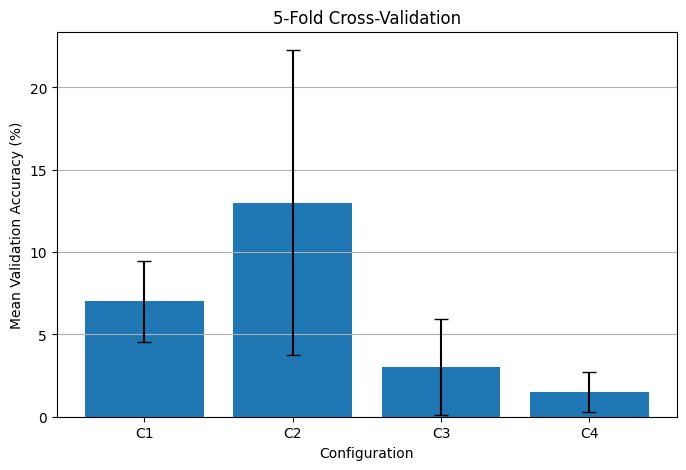

In [8]:
# ============================================================
# TASK 8 - 5-FOLD CROSS VALIDATION
# ============================================================

import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DATA
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

# ONLY 200 IMAGES
dataset = Subset(dataset, range(200))

indices = np.arange(200)

# 4 configurations
configs = {
    "C1": (1e-4, 0),
    "C2": (1e-4, 0.25),
    "C3": (1e-5, 0.25),
    "C4": (1e-5, 0.5)
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

for config_name, (lr, dropout) in configs.items():

    print("\n======================")
    print(config_name)
    print("======================")

    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(indices)
    ):

        print("Fold", fold + 1)

        train_subset = Subset(
            dataset,
            train_idx
        )

        val_subset = Subset(
            dataset,
            val_idx
        )

        train_loader = DataLoader(
            train_subset,
            batch_size=32,
            shuffle=True,
            num_workers=0
        )

        val_loader = DataLoader(
            val_subset,
            batch_size=32,
            shuffle=False,
            num_workers=0
        )

        # PRETRAINED MODEL
        model = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.DEFAULT
        )

        # FREEZE FEATURES
        for p in model.features.parameters():
            p.requires_grad = False

        model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(model.last_channel, 37)
        )

        model = model.to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = optim.Adam(
            model.classifier.parameters(),
            lr=lr
        )

        # ONE EPOCH
        model.train()

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad(set_to_none=True)

            output = model(x)

            loss = criterion(output, y)

            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)
                y = y.to(device)

                output = model(x)

                pred = output.argmax(1)

                correct += (
                    pred == y
                ).sum().item()

                total += y.size(0)

        accuracy = 100 * correct / total

        fold_scores.append(accuracy)

        print(
            f"Accuracy: {accuracy:.2f}%"
        )

        # FREE MEMORY
        del model
        gc.collect()
        torch.cuda.empty_cache()

    mean = np.mean(fold_scores)
    std = np.std(fold_scores)

    results[config_name] = {
        "folds": fold_scores,
        "mean": mean,
        "std": std
    }

    print(
        f"Mean ± SD: "
        f"{mean:.2f} ± {std:.2f}"
    )


# TABLE
rows = []

for name, result in results.items():

    rows.append([
        name,
        *result["folds"],
        result["mean"],
        result["std"]
    ])

df = pd.DataFrame(
    rows,
    columns=[
        "Configuration",
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5",
        "Mean",
        "SD"
    ]
)

print("\nFINAL TABLE")
print(df)


# PLOT
names = list(results.keys())

means = [
    results[x]["mean"]
    for x in names
]

stds = [
    results[x]["std"]
    for x in names
]

plt.figure(figsize=(8, 5))

plt.bar(
    names,
    means,
    yerr=stds,
    capsize=5
)

plt.xlabel("Configuration")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("5-Fold Cross-Validation")
plt.grid(axis="y")

plt.show()

Device: cuda

Training final model...
Testing...

FINAL TEST RESULTS
Accuracy  : 4.36%
Precision : 0.0220
Recall    : 0.0435
F1 Score  : 0.0182
Training Time : 5.32 seconds

Total Parameters: 2,271,269
Trainable Parameters: 47,397


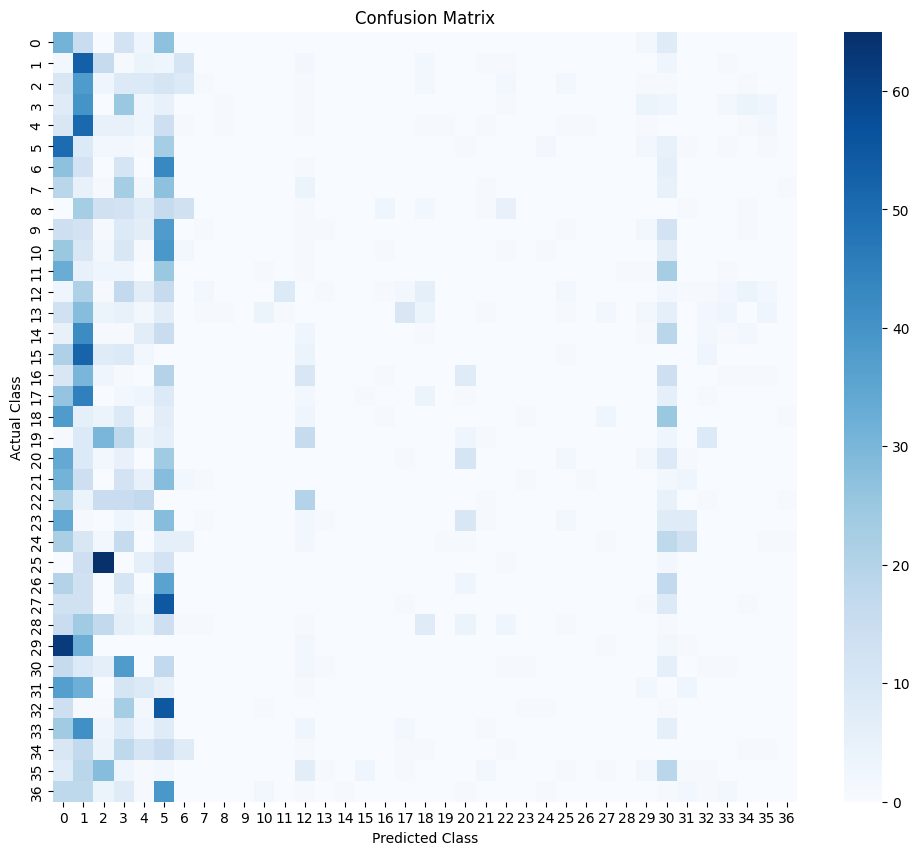

In [9]:
# ============================================================
# TASK 9 - FINAL MODEL EVALUATION
# ============================================================

import gc
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# BEST CONFIGURATION
# Change according to Task 8
# ============================================================

LR = 1e-4
DROPOUT = 0.25
BATCH_SIZE = 32

# ============================================================
# TRANSFORM
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ============================================================
# TRAIN DATA
# ============================================================

train_dataset = datasets.OxfordIIITPet(
    "./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

# FAST VERSION
train_dataset = Subset(
    train_dataset,
    range(300)
)

# ============================================================
# TEST DATA
# ============================================================

test_dataset = datasets.OxfordIIITPet(
    "./data",
    split="test",
    target_types="category",
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# ============================================================
# MODEL
# ============================================================

model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

# Freeze feature extractor
for p in model.features.parameters():
    p.requires_grad = False

# Final classifier
model.classifier = nn.Sequential(
    nn.Dropout(DROPOUT),
    nn.Linear(
        model.last_channel,
        37
    )
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=LR
)

# ============================================================
# TRAIN
# ============================================================

print("\nTraining final model...")

start = time.time()

model.train()

for x, y in train_loader:

    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad(set_to_none=True)

    output = model(x)

    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

training_time = time.time() - start

# ============================================================
# TEST
# ============================================================

print("Testing...")

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        output = model(x)

        prediction = output.argmax(1)

        y_true.extend(
            y.numpy()
        )

        y_pred.extend(
            prediction.cpu().numpy()
        )

# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("\n================================")
print("FINAL TEST RESULTS")
print("================================")

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

print(
    f"Training Time : {training_time:.2f} seconds"
)

# ============================================================
# PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"\nTotal Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

# FREE MEMORY
del model
gc.collect()
torch.cuda.empty_cache()